# Model-dependent analysis 

We have some data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import _fig_params

In [2]:
np.random.seed(1)

In [3]:
def arrhenius(x, ea, k):
    return k * np.exp(-ea / (8.617e-5 * x))

In [4]:
T = np.array([-9.5, 0.5, 10.5, 19.5, 30, 50]) + 273.15

In [38]:
D = np.exp(-0.62/(8.617e-5 * T)) * 9e11 + np.random.randn(T.size) * 7.5
Derr = np.ones_like(D) * 5000 / T

In [39]:
D, Derr

(array([ -3.42170056,  19.65417129,  13.31697225,  14.77476518,
         53.40611101, 200.66494976]),
 array([18.96453632, 18.27151471, 17.62735766, 17.08525542, 16.49348507,
        15.4726907 ]))

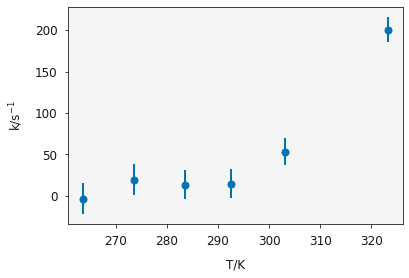

In [40]:
plt.errorbar(T, D, Derr, marker='o', ls='')
plt.ylabel('k/s$^{-1}$')
plt.xlabel('T/K')
plt.savefig('figures/data.png', dpi=600)
plt.show()

In [41]:
popt, pcov = curve_fit(arrhenius, T, D, p0=[0.62, 9e11], sigma=Derr)

In [42]:
popt[0], np.sqrt(pcov[0][0])

(0.5764135091846302, 0.053856002798488796)

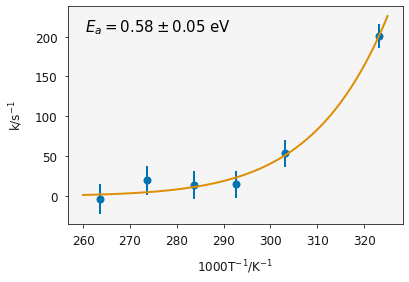

In [43]:
fig, ax = plt.subplots()
plt.errorbar(T, D, Derr, marker='o', ls='')
T_nice = np.linspace(260, 325, 100)
plt.plot(T_nice, arrhenius(T_nice, *popt), zorder=10)
plt.ylabel('k/s$^{-1}$')
plt.xlabel('1000T$^{-1}$/K$^{-1}$')
Ea = -np.array([popt[0], np.sqrt(np.diag(pcov)[0])]) * 8.617e-5
ax.text(0.05, 0.95, '$E_a={0:.2f}\pm{1:.2f}$ eV'.format(
    popt[0], np.sqrt(np.diag(pcov)[0])), 
        horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
plt.savefig('figures/straight_line.png', dpi=600)
plt.show()

In [44]:
xk = np.linspace(-50, 325, 100)

In [45]:
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [46]:
x = T
y = D
yerr = Derr

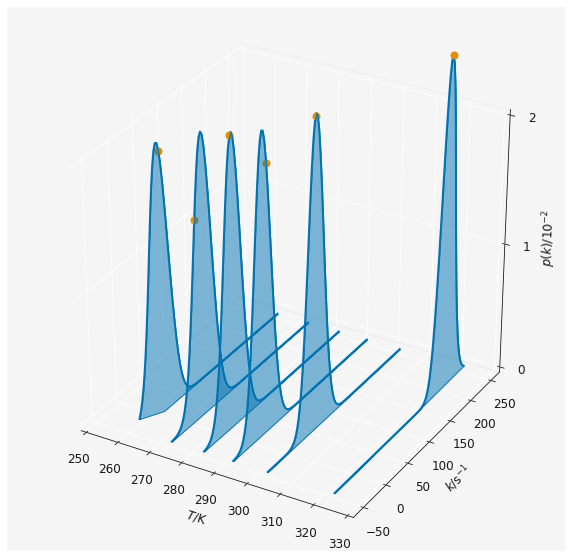

In [47]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
zstore = []
for i in range(len(y)):
    x1 = np.array([x[i]]*100)
    x2 = np.linspace(-50, 250, 100)
    x3 = norm.pdf(x2, loc=y[i], scale=yerr[i]) * 100
    verts = [(x1[i],x2[i],x3[i]) for i in range(len(x1))] + [(x1.max(),0,0),(x1.min(),0,0)]
    ax.add_collection3d(Poly3DCollection([verts],color=_fig_params.colors[0], alpha=0.5))
    ax.plot(x1, x2, x3, color=_fig_params.colors[0], alpha=1)
    zstore.append(norm.pdf(arrhenius(x[i], *popt), loc=y[i], scale=yerr[i]))
ax.plot(x, arrhenius(x, *popt), np.array(zstore) * 100, 'o', color=_fig_params.colors[1])
ax.set_zlim(0, 2)    
ax.set_xlim(250, 330)
ax.set_ylabel('$k$/s$^{-1}$')
ax.set_xlabel('$T$/K')
ax.set_zlabel('$p(k)$/$10^{-2}$')
ax.set_zticks([0, 1, 2])
ax.grid(True)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
plt.savefig('figures/prob.png', dpi=600)

In [15]:
from uravu.relationship import Relationship

In [24]:
r = Relationship(arrhenius, T, D, ordinate_error=Derr, bounds=((0, 2), (1e10, 1e20)))

In [25]:
r.max_likelihood('diff_evo')

In [26]:
r.mcmc()

100%|██████████| 1000/1000 [00:45<00:00, 22.09it/s]


In [27]:
r.variables[0].samples

array([1.1263278 , 1.10823334, 1.09301068, ..., 1.08721369, 1.08765772,
       1.13605101])

In [28]:
flat_samples = np.array([r.variables[0].samples, r.variables[1].samples]).T
print(flat_samples.shape)

(25000, 2)


In [29]:
from uravu import plotting

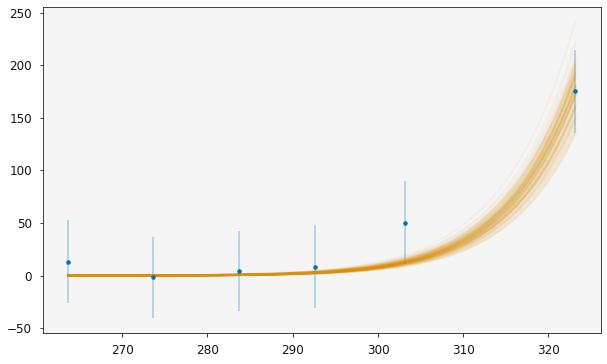

In [30]:
plotting.plot_relationship(r)

(<Figure size 576x576 with 4 Axes>,
 array([[<matplotlib.axes._subplots.AxesSubplot object at 0x1221bbd50>,
       dtype=object))

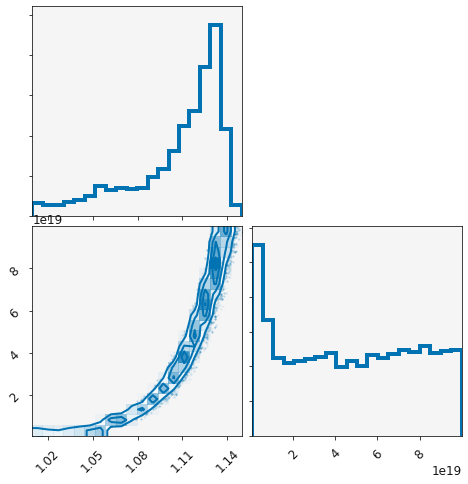

In [31]:
plotting.plot_corner(r)